In [2]:
!pip install -q "gymnasium[mujoco]" mujoco torch numpy matplotlib
print("Done")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 25.9 MB/s eta 0:00:00
Done


In [3]:
import os, json, time, copy, math
from pathlib import Path
from collections import deque

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda": print(f"GPU: {torch.cuda.get_device_name(0)}")

_env = gym.make("Hopper-v5")
STATE_DIM  = _env.observation_space.shape[0]   # 11
ACTION_DIM = _env.action_space.shape[0]        # 3
MAX_ACTION = float(_env.action_space.high[0])  # 1.0
_env.close()
print(f"Hopper-v5: state={STATE_DIM}, action={ACTION_DIM}, max_action={MAX_ACTION}")


Device: cuda
GPU: Tesla T4
Hopper-v5: state=11, action=3, max_action=1.0


In [4]:
# TD3 config — identical to Phase B1 for fair comparison
TD3_CFG = {
    "env_name"      : "Hopper-v5",
    "seed"          : 42,
    "total_steps"   : 300_000,
    "warmup_steps"  : 25_000,
    "batch_size"    : 256,
    "discount"      : 0.99,
    "tau"           : 0.005,        # Polyak coefficient
    "policy_noise"  : 0.2,          # target smoothing noise sigma
    "noise_clip"    : 0.5,          # target noise clip range
    "policy_delay"  : 2,            # update actor every N critic steps
    "expl_noise"    : 0.1,          # exploration noise sigma
    "buffer_size"   : 1_000_000,
    "eval_every"    : 10_000,
    "eval_episodes" : 10,
    "log_every"     : 2_000,
    "save_dir"      : "./checkpoints_rl_b2",
    "critic_hidden" : 256,
    "critic_lr"     : 3e-4,
    "actor_lr"      : 1e-4,         # slightly lower for Transformer stability
}

# Transformer actor architecture
TF_CFG = {
    "d_model"         : 128,        # embedding dim (small for RL speed)
    "n_heads"         : 4,
    "n_layers"        : 2,          # shallow — forward pass speed matters
    "d_ff"            : 256,        # 2 × d_model
    "dropout"         : 0.1,
    "context_lengths" : [4, 16],
}

print("TD3 Config:", {k:v for k,v in TD3_CFG.items() if k != "save_dir"})
print("\nTransformer Config:", {k:v for k,v in TF_CFG.items()})


TD3 Config: {'env_name': 'Hopper-v5', 'seed': 42, 'total_steps': 300000, 'warmup_steps': 25000, 'batch_size': 256, 'discount': 0.99, 'tau': 0.005, 'policy_noise': 0.2, 'noise_clip': 0.5, 'policy_delay': 2, 'expl_noise': 0.1, 'buffer_size': 1000000, 'eval_every': 10000, 'eval_episodes': 10, 'log_every': 2000, 'critic_hidden': 256, 'critic_lr': 0.0003, 'actor_lr': 0.0001}

Transformer Config: {'d_model': 128, 'n_heads': 4, 'n_layers': 2, 'd_ff': 256, 'dropout': 0.1, 'context_lengths': [4, 16]}


In [5]:
class ReplayBuffer:
    """Pre-allocated circular buffer — identical to Phase B1."""
    def __init__(self, state_dim, action_dim, max_size=1_000_000,
                 device=torch.device("cpu")):
        self.max_size = max_size; self.device = device
        self.ptr = 0; self.size = 0
        self.states      = np.zeros((max_size, state_dim),  dtype=np.float32)
        self.actions     = np.zeros((max_size, action_dim), dtype=np.float32)
        self.rewards     = np.zeros((max_size, 1),          dtype=np.float32)
        self.next_states = np.zeros((max_size, state_dim),  dtype=np.float32)
        self.dones       = np.zeros((max_size, 1),          dtype=np.float32)

    def add(self, s, a, r, s2, done):
        self.states[self.ptr]=s; self.actions[self.ptr]=a
        self.rewards[self.ptr]=r; self.next_states[self.ptr]=s2
        self.dones[self.ptr]=float(done)
        self.ptr = (self.ptr+1)%self.max_size
        self.size = min(self.size+1, self.max_size)

    def sample(self, batch_size):
        idx = np.random.randint(0, self.size, size=batch_size)
        return {k: torch.as_tensor(v[idx], device=self.device)
                for k, v in [("states",self.states),("actions",self.actions),
                              ("rewards",self.rewards),("next_states",self.next_states),
                              ("dones",self.dones)]}
    def __len__(self): return self.size

print("ReplayBuffer defined.")


ReplayBuffer defined.


In [6]:
class ObsActionHistory:
    """
    Sliding window of (obs, action) pairs for a single environment episode.

    Maintains a deque of length context_len.
    At each step, get_sequence(current_obs) returns shape (L, obs_dim+action_dim):
        rows  0..L-2  =  past (obs, action) pairs (oldest first)
        row     L-1   =  (current_obs, ZEROS)  <- query token to be predicted

    Call reset() at episode start. Call push(obs, action) after each step.
    """
    def __init__(self, obs_dim: int, action_dim: int, context_len: int):
        self.obs_dim     = obs_dim
        self.action_dim  = action_dim
        self.context_len = context_len
        self.reset()

    def reset(self):
        """Fill with zeros at episode start."""
        self.buffer = deque(
            [np.zeros(self.obs_dim + self.action_dim, dtype=np.float32)
             for _ in range(self.context_len)],
            maxlen=self.context_len
        )

    def push(self, obs: np.ndarray, action: np.ndarray):
        """Store completed (obs, action) transition."""
        self.buffer.append(
            np.concatenate([obs, action]).astype(np.float32)
        )

    def get_sequence(self, current_obs: np.ndarray) -> np.ndarray:
        """
        Build the (L, obs+act) input sequence for the Transformer.
        Last row has action=0 because we are predicting this action.
        """
        seq = np.array(self.buffer, dtype=np.float32)  # (L, obs+act)
        # Replace last slot: current_obs + zero action (query)
        seq[-1] = np.concatenate(
            [current_obs, np.zeros(self.action_dim)]
        ).astype(np.float32)
        return seq  # (L, obs_dim + action_dim)


# ── Verify causality ──────────────────────────────────────────────────────
_h = ObsActionHistory(obs_dim=11, action_dim=3, context_len=4)
for i in range(6):
    o = np.random.randn(11).astype(np.float32)
    a = np.random.randn(3).astype(np.float32)
    seq = _h.get_sequence(o)
    _h.push(o, a)

print(f"History buffer: seq shape = {seq.shape}")
print(f"Last row action (should be zeros): {seq[-1, 11:].round(3)}")
print(f"Second-to-last row action (real): {seq[-2, 11:].round(3)}")
del _h


History buffer: seq shape = (4, 14)
Last row action (should be zeros): [0. 0. 0.]
Second-to-last row action (real): [0.612 1.031 0.931]


In [7]:
# ── Sinusoidal Positional Encoding (fixed, not learned) ──────────────────
class SinusoidalPE(nn.Module):
    """
    Fixed sinusoidal PE from Vaswani et al., 2017.
    Using fixed (not learned) so the actor works at any context length.

    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """
    def __init__(self, d_model: int, max_len: int = 64, dropout: float = 0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float)
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe)  # (max_len, d_model)

    def forward(self, x):  # x: (B, T, d_model)
        return self.drop(x + self.pe[:x.size(1)].unsqueeze(0))


# ── Causal Multi-Head Self-Attention ─────────────────────────────────────
class CausalMHSA(nn.Module):
    """Causal MHSA — same as Core ML Phase 1."""
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model; self.n_heads = n_heads
        self.d_head  = d_model // n_heads
        self.scale   = self.d_head ** -0.5
        self.qkv        = nn.Linear(d_model, 3*d_model, bias=False)
        self.out_proj   = nn.Linear(d_model, d_model,   bias=False)
        self.attn_drop  = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(self.d_model, dim=-1)
        def rsh(t): return t.view(B,T,self.n_heads,self.d_head).transpose(1,2)
        q, k, v = rsh(q), rsh(k), rsh(v)
        scores = torch.matmul(q, k.transpose(-2,-1)) * self.scale
        mask   = torch.triu(
            torch.ones(T,T, device=x.device, dtype=torch.bool), diagonal=1
        )
        scores = scores.masked_fill(mask, float("-inf"))
        w      = self.attn_drop(F.softmax(scores, dim=-1))
        out    = torch.matmul(w, v).transpose(1,2).contiguous().view(B,T,C)
        return self.resid_drop(self.out_proj(out)), w


# ── Pre-LN Transformer Block ─────────────────────────────────────────────
class TFBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.ln1  = nn.LayerNorm(d_model)
        self.attn = CausalMHSA(d_model, n_heads, dropout)
        self.ln2  = nn.LayerNorm(d_model)
        self.ff   = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )
    def forward(self, x):
        a, w = self.attn(self.ln1(x)); x = x + a
        return x + self.ff(self.ln2(x)), w


# ── Transformer Actor ─────────────────────────────────────────────────────
class TransformerActor(nn.Module):
    """
    Causal Transformer policy for TD3.

    Input  : (B, L, obs_dim + action_dim)  — history sequence
    Output : (B, action_dim)               — action at last (current) position

    Key design decisions:
    - Sinusoidal PE (fixed) — generalises to any L at eval
    - Shallow (n_layers=2, d_model=128) — RL needs fast inference
    - Last-position extraction — only output at idx L-1 is used
    - tanh output × max_action — keeps actions in valid range
    """
    def __init__(self, obs_dim, action_dim, max_action, context_len,
                 d_model=128, n_heads=4, n_layers=2, d_ff=256, dropout=0.1):
        super().__init__()
        self.obs_dim     = obs_dim
        self.action_dim  = action_dim
        self.max_action  = max_action
        self.context_len = context_len

        # Project each (obs, act) token → d_model
        self.input_proj = nn.Linear(obs_dim + action_dim, d_model)
        self.pos_enc    = SinusoidalPE(d_model, max_len=context_len+8, dropout=dropout)

        self.blocks = nn.ModuleList([
            TFBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.ln_out   = nn.LayerNorm(d_model)
        # Two-layer output head with ReLU then Tanh
        self.out_head = nn.Sequential(
            nn.Linear(d_model, d_model), nn.ReLU(),
            nn.Linear(d_model, action_dim), nn.Tanh(),
        )
        self.apply(self._init_weights)
        n = sum(p.numel() for p in self.parameters())
        print(f"TransformerActor  L={context_len}  d={d_model}  "
              f"layers={n_layers}  heads={n_heads}  → {n:,} params")

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, seq: torch.Tensor) -> torch.Tensor:
        """seq: (B, L, obs+act) → action: (B, action_dim)"""
        x = self.pos_enc(self.input_proj(seq))   # (B, L, d_model)
        for blk in self.blocks:
            x, _ = blk(x)
        x = self.ln_out(x[:, -1, :])             # LAST position only → (B, d_model)
        return self.max_action * self.out_head(x) # (B, action_dim)

    def get_attn_weights(self, seq: torch.Tensor):
        """Forward pass that also returns all attention weight tensors."""
        x = self.pos_enc(self.input_proj(seq))
        attn_weights = []
        for blk in self.blocks:
            x, w = blk(x); attn_weights.append(w)
        return self.max_action * self.out_head(self.ln_out(x[:,-1,:])), attn_weights


# ── Test all context lengths ────────────────────────────────────────────────
print("\nTesting TransformerActor for all context lengths:\n")
for L in TF_CFG["context_lengths"]:
    kw  = {k:v for k,v in TF_CFG.items() if k != "context_lengths"}
    _tf = TransformerActor(STATE_DIM, ACTION_DIM, MAX_ACTION, L, **kw)
    _s  = torch.randn(2, L, STATE_DIM + ACTION_DIM)
    _a  = _tf(_s)
    assert _a.shape == (2, ACTION_DIM), f"Bad output shape: {_a.shape}"
    assert _a.abs().max().item() <= MAX_ACTION + 1e-5, "Action out of range"
    print(f"  ✔  L={L:2d}  output: {_a.shape}  "
          f"range: [{_a.min().item():.3f}, {_a.max().item():.3f}]")
    del _tf, _s, _a
print("\nAll context lengths verified.")



Testing TransformerActor for all context lengths:

TransformerActor  L=4  d=128  layers=2  heads=4  → 283,011 params
  ✔  L= 4  output: torch.Size([2, 3])  range: [-0.888, 0.853]
TransformerActor  L=16  d=128  layers=2  heads=4  → 283,011 params
  ✔  L=16  output: torch.Size([2, 3])  range: [-0.973, 0.632]

All context lengths verified.


In [8]:
class Critic(nn.Module):
    """
    Twin Q-networks — identical to Phase B1.
    Input: (state, action) concatenated → scalar Q-value.
    No history: the critic sees single transitions, not sequences.
    """
    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super().__init__()
        inp = state_dim + action_dim
        def make_q():
            return nn.Sequential(
                nn.Linear(inp, hidden_dim), nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                nn.Linear(hidden_dim, 1),
            )
        self.q1 = make_q()
        self.q2 = make_q()
        self.apply(self._init)

    def _init(self, m):
        if isinstance(m, nn.Linear):
            nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
            nn.init.zeros_(m.bias)

    def forward(self, state, action):
        sa = torch.cat([state, action], dim=-1)
        return self.q1(sa), self.q2(sa)

    def Q1(self, state, action):
        return self.q1(torch.cat([state, action], dim=-1))

print(f"Critic: {sum(p.numel() for p in Critic(STATE_DIM,ACTION_DIM).parameters()):,} params")


Critic: 139,778 params


In [9]:
class TransformerTD3Agent:
    """
    TD3 agent with Transformer actor and MLP critic.

    KEY DESIGN: The replay buffer stores individual (s,a,r,s',done) transitions
    (no history). During rollout, ObsActionHistory provides the sequence.
    During training updates, we pad the state to a length-1 sequence
    (L-1 zero tokens + current state token). This is a standard approximation
    that avoids storing full histories in the replay buffer.
    """
    def __init__(self, obs_dim, action_dim, max_action, context_len,
                 td3_cfg, tf_cfg, device):
        self.cfg        = td3_cfg
        self.device     = device
        self.max_action = max_action
        self.context_len = context_len
        self.total_it   = 0
        self.obs_dim    = obs_dim
        self.action_dim = action_dim

        kw = {k:v for k,v in tf_cfg.items() if k != "context_lengths"}
        self.actor         = TransformerActor(obs_dim, action_dim, max_action,
                                              context_len, **kw).to(device)
        self.actor_target  = copy.deepcopy(self.actor)
        self.critic        = Critic(obs_dim, action_dim,
                                    td3_cfg["critic_hidden"]).to(device)
        self.critic_target = copy.deepcopy(self.critic)

        for p in self.actor_target.parameters():  p.requires_grad = False
        for p in self.critic_target.parameters(): p.requires_grad = False

        self.actor_opt  = torch.optim.Adam(self.actor.parameters(),
                                           lr=td3_cfg["actor_lr"])
        self.critic_opt = torch.optim.Adam(self.critic.parameters(),
                                           lr=td3_cfg["critic_lr"])
        self.critic_losses = []
        self.actor_losses  = []

    # ── Helper: pad a batch of flat states to a length-L sequence ───────────
    def _pad_to_seq(self, states: torch.Tensor) -> torch.Tensor:
        """
        Build (B, L, obs+act) sequence from flat states (B, obs_dim).

        Padding: L-1 zero tokens + (state, zero_action) query token.
        This approximates 'the agent has no prior history' for the
        off-policy training batch — simple and works well in practice.
        """
        B = states.shape[0]
        D = self.obs_dim + self.action_dim
        zeros_hist = torch.zeros(B, self.context_len - 1, D, device=self.device)
        query = torch.cat(
            [states, torch.zeros(B, self.action_dim, device=self.device)],
            dim=-1
        ).unsqueeze(1)                                        # (B, 1, obs+act)
        return torch.cat([zeros_hist, query], dim=1)         # (B, L, obs+act)

    # ── Action selection (used during rollout, with real history) ────────────
    def select_action(self, history_seq: np.ndarray,
                      add_noise: bool = True) -> np.ndarray:
        """
        Args:
            history_seq : (L, obs+act) from ObsActionHistory.get_sequence()
            add_noise   : True during training, False during evaluation
        """
        seq_t = torch.tensor(
            history_seq, dtype=torch.float32, device=self.device
        ).unsqueeze(0)   # (1, L, obs+act)

        self.actor.eval()
        with torch.no_grad():
            action = self.actor(seq_t).squeeze(0).cpu().numpy()
        self.actor.train()

        if add_noise:
            noise  = np.random.normal(
                0, self.cfg["expl_noise"] * self.max_action, size=action.shape
            )
            action = np.clip(action + noise, -self.max_action, self.max_action)
        return action

    # ── TD3 training step ───────────────────────────────────────────────────
    def train_step(self, replay_buffer: ReplayBuffer) -> dict:
        self.total_it += 1
        batch = replay_buffer.sample(self.cfg["batch_size"])
        s, a, r = batch["states"], batch["actions"], batch["rewards"]
        s2, d   = batch["next_states"], batch["dones"]

        # ── Compute target Q-value ─────────────────────────────────────────
        with torch.no_grad():
            seq_s2 = self._pad_to_seq(s2)
            noise  = (torch.randn_like(a) * self.cfg["policy_noise"]).clamp(
                        -self.cfg["noise_clip"], self.cfg["noise_clip"])
            a2 = (self.actor_target(seq_s2) + noise).clamp(
                    -self.max_action, self.max_action)
            q1t, q2t = self.critic_target(s2, a2)
            y = r + self.cfg["discount"] * torch.min(q1t, q2t) * (1.0 - d)

        # ── Critic update (both Q-networks) ───────────────────────────────
        q1, q2 = self.critic(s, a)
        closs  = F.mse_loss(q1, y) + F.mse_loss(q2, y)
        self.critic_opt.zero_grad()
        closs.backward()
        nn.utils.clip_grad_norm_(self.critic.parameters(), max_norm=10.0)
        self.critic_opt.step()
        self.critic_losses.append(closs.item())
        log = {"critic_loss": closs.item(), "actor_loss": None}

        # ── Delayed actor update ───────────────────────────────────────────
        if self.total_it % self.cfg["policy_delay"] == 0:
            seq_s  = self._pad_to_seq(s)
            aloss  = -self.critic.Q1(s, self.actor(seq_s)).mean()
            self.actor_opt.zero_grad()
            aloss.backward()
            nn.utils.clip_grad_norm_(self.actor.parameters(), max_norm=10.0)
            self.actor_opt.step()
            self.actor_losses.append(aloss.item())
            log["actor_loss"] = aloss.item()

            # Polyak (soft) target update
            tau = self.cfg["tau"]
            for p, tp in zip(self.actor.parameters(),
                             self.actor_target.parameters()):
                tp.data.mul_(1 - tau).add_(p.data, alpha=tau)
            for p, tp in zip(self.critic.parameters(),
                             self.critic_target.parameters()):
                tp.data.mul_(1 - tau).add_(p.data, alpha=tau)

        return log

    def save(self, path):
        Path(path).parent.mkdir(parents=True, exist_ok=True)
        torch.save({
            "actor"        : self.actor.state_dict(),
            "actor_target" : self.actor_target.state_dict(),
            "critic"       : self.critic.state_dict(),
            "critic_target": self.critic_target.state_dict(),
            "actor_opt"    : self.actor_opt.state_dict(),
            "critic_opt"   : self.critic_opt.state_dict(),
            "total_it"     : self.total_it,
            "context_len"  : self.context_len,
        }, path)

    def load(self, path):
        c = torch.load(path, map_location=self.device)
        self.actor.load_state_dict(c["actor"])
        self.actor_target.load_state_dict(c["actor_target"])
        self.critic.load_state_dict(c["critic"])
        self.critic_target.load_state_dict(c["critic_target"])
        self.actor_opt.load_state_dict(c["actor_opt"])
        self.critic_opt.load_state_dict(c["critic_opt"])
        self.total_it = c["total_it"]
        print(f"  Loaded checkpoint  step={self.total_it}  L={c['context_len']}")

print("TransformerTD3Agent defined.")


TransformerTD3Agent defined.


In [10]:
def evaluate_policy(agent, env_name, seed, n_episodes=10):
    """
    Deterministic evaluation with fresh history buffer per episode.
    No exploration noise. History accumulates within each episode.
    """
    eval_env = gym.make(env_name)
    returns  = []

    for ep in range(n_episodes):
        obs, _  = eval_env.reset(seed=seed + ep)
        history = ObsActionHistory(STATE_DIM, ACTION_DIM, agent.context_len)
        ep_ret  = 0.0; done = False

        while not done:
            seq    = history.get_sequence(obs)
            action = agent.select_action(seq, add_noise=False)
            history.push(obs, action)
            obs, reward, terminated, truncated, _ = eval_env.step(action)
            ep_ret += reward
            done = terminated or truncated

        returns.append(ep_ret)

    eval_env.close()
    arr = np.array(returns)
    return {"mean": arr.mean(), "std": arr.std(),
            "min": arr.min(), "max": arr.max(), "all": arr.tolist()}

print("evaluate_policy() defined.")


evaluate_policy() defined.


In [11]:
def train_agent(agent, td3_cfg, label):
    """Train one Transformer-TD3 agent for td3_cfg['total_steps'] steps."""
    os.makedirs(td3_cfg["save_dir"], exist_ok=True)

    env    = gym.make(td3_cfg["env_name"])
    buffer = ReplayBuffer(STATE_DIM, ACTION_DIM,
                          td3_cfg["buffer_size"], DEVICE)
    history = {
        "ep_rets": [], "ep_steps": [],
        "eval_means": [], "eval_stds": [], "eval_steps": [],
        "closs": [], "aloss": [], "lsteps": [],
    }

    obs, _   = env.reset(seed=td3_cfg["seed"])
    hist_buf = ObsActionHistory(STATE_DIM, ACTION_DIM, agent.context_len)
    ep_ret = ep_n = total_ep = 0
    t_start = time.time()

    print(f"\n{'='*60}")
    print(f"  [{label}]  context_len={agent.context_len}  "
          f"total_steps={td3_cfg['total_steps']:,}")
    print(f"{'='*60}")

    for t in range(1, td3_cfg["total_steps"] + 1):

        # ── Action selection ──────────────────────────────────────────────
        if t < td3_cfg["warmup_steps"]:
            action = env.action_space.sample()   # random during warm-up
        else:
            seq    = hist_buf.get_sequence(obs)
            action = agent.select_action(seq, add_noise=True)

        # ── Environment step ──────────────────────────────────────────────
        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Store transition (single step — NOT the full sequence)
        # Note: store float(terminated), not float(done).
        # Truncation is NOT a true episode end — the agent didn't fail.
        buffer.add(obs, action, reward, next_obs, float(terminated))
        hist_buf.push(obs, action)   # update sliding window

        obs = next_obs; ep_ret += reward; ep_n += 1

        # ── Episode end ───────────────────────────────────────────────────
        if done:
            history["ep_rets"].append(ep_ret)
            history["ep_steps"].append(t)
            total_ep += 1
            if t % td3_cfg["log_every"] < ep_n:
                fps = t / (time.time() - t_start)
                print(f"  [{label}] Step {t:>8,} | Ep {total_ep:>4} | "
                      f"Return {ep_ret:>8.1f} | FPS {fps:>5.0f}")
            obs, _   = env.reset()
            hist_buf.reset()      # ← IMPORTANT: clear history each new episode
            ep_ret = ep_n = 0

        # ── TD3 update ────────────────────────────────────────────────────
        if t >= td3_cfg["warmup_steps"] and len(buffer) >= td3_cfg["batch_size"]:
            log = agent.train_step(buffer)
            history["closs"].append(log["critic_loss"])
            history["lsteps"].append(t)
            if log["actor_loss"] is not None:
                history["aloss"].append(log["actor_loss"])

        # ── Periodic evaluation ───────────────────────────────────────────
        if t % td3_cfg["eval_every"] == 0:
            ev = evaluate_policy(
                agent, td3_cfg["env_name"],
                seed=td3_cfg["seed"] + 1000,
                n_episodes=td3_cfg["eval_episodes"],
            )
            history["eval_means"].append(ev["mean"])
            history["eval_stds"].append(ev["std"])
            history["eval_steps"].append(t)
            elapsed = (time.time() - t_start) / 60
            print(f"  [{label}] ── EVAL Step {t:>8,} | "
                  f"Mean {ev['mean']:>8.1f} ± {ev['std']:.1f} | "
                  f"{elapsed:.1f} min")
            agent.save(f"{td3_cfg['save_dir']}/{label}_step_{t:07d}.pt")

    agent.save(f"{td3_cfg['save_dir']}/{label}_final.pt")
    env.close()
    history["final_return"] = (
        history["eval_means"][-1] if history["eval_means"] else 0
    )
    total_time = (time.time() - t_start) / 60
    print(f"\n  [{label}] Done in {total_time:.1f} min. "
          f"Final eval: {history['final_return']:.1f}")
    return history

print("train_agent() defined.")


train_agent() defined.


In [12]:
# ── Context-length sweep: L ∈ {4, 8, 16, 32} ─────────────────────────────
# Runtime: ~60-90 min per variant × 4 = ~4-6 hours total.
# Tip: Run L=4 and L=16 first if short on time.
#
# To resume after a Colab disconnect:
#   agent.load(f"{TD3_CFG['save_dir']}/TransformerTD3_L{L}_step_XXXXXXX.pt")
# then call train_agent(...) — it will continue from the loaded step.

all_histories = {}
all_agents    = {}

for L in TF_CFG["context_lengths"]:
    label = f"TransformerTD3_L{L}"
    print(f"\n\nStarting {label} …")

    agent = TransformerTD3Agent(
        obs_dim     = STATE_DIM,
        action_dim  = ACTION_DIM,
        max_action  = MAX_ACTION,
        context_len = L,
        td3_cfg     = TD3_CFG,
        tf_cfg      = TF_CFG,
        device      = DEVICE,
    )

    # ── Resume (uncomment if restarting) ─────────────────────────────────
    # agent.load(f"{TD3_CFG['save_dir']}/{label}_step_XXXXXXX.pt")

    hist = train_agent(agent, TD3_CFG, label)
    all_histories[L] = hist
    all_agents[L]    = agent

print("\n\nAll variants trained.")




Starting TransformerTD3_L4 …
TransformerActor  L=4  d=128  layers=2  heads=4  → 283,011 params

  [TransformerTD3_L4]  context_len=4  total_steps=300,000
  [TransformerTD3_L4] Step    2,004 | Ep  100 | Return     18.7 | FPS  2506
  [TransformerTD3_L4] Step    4,025 | Ep  184 | Return     48.3 | FPS  2905
  [TransformerTD3_L4] Step    6,005 | Ep  272 | Return     10.6 | FPS  3119
  [TransformerTD3_L4] Step    8,010 | Ep  358 | Return     12.5 | FPS  3214
  [TransformerTD3_L4] ── EVAL Step   10,000 | Mean      1.5 ± 0.2 | 0.1 min
  [TransformerTD3_L4] Step   10,026 | Ep  450 | Return     33.4 | FPS  2433
  [TransformerTD3_L4] Step   12,005 | Ep  537 | Return     12.7 | FPS  2554
  [TransformerTD3_L4] Step   14,014 | Ep  637 | Return     11.2 | FPS  2670
  [TransformerTD3_L4] Step   16,018 | Ep  727 | Return     23.2 | FPS  2746
  [TransformerTD3_L4] Step   18,009 | Ep  820 | Return     58.4 | FPS  2733
  [TransformerTD3_L4] Step   20,000 | Ep  901 | Return     10.1 | FPS  2728
  [Trans

Phase B1 summary not found. Set b1_return manually if needed.


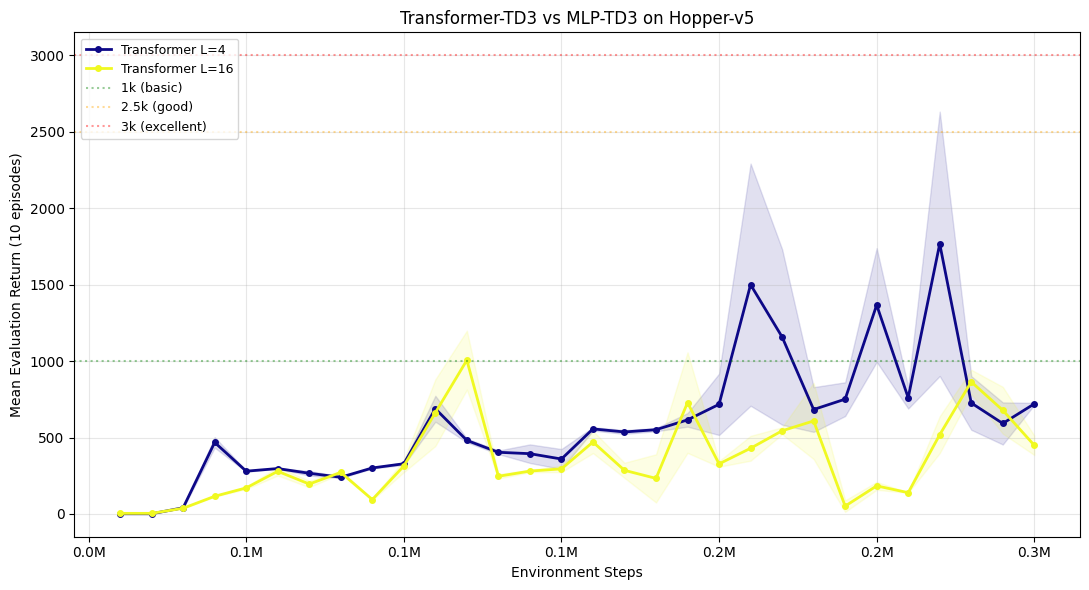

Saved → tf_td3_curves.png
TransformerActor  L=4  d=128  layers=2  heads=4  → 283,011 params
TransformerActor  L=16  d=128  layers=2  heads=4  → 283,011 params


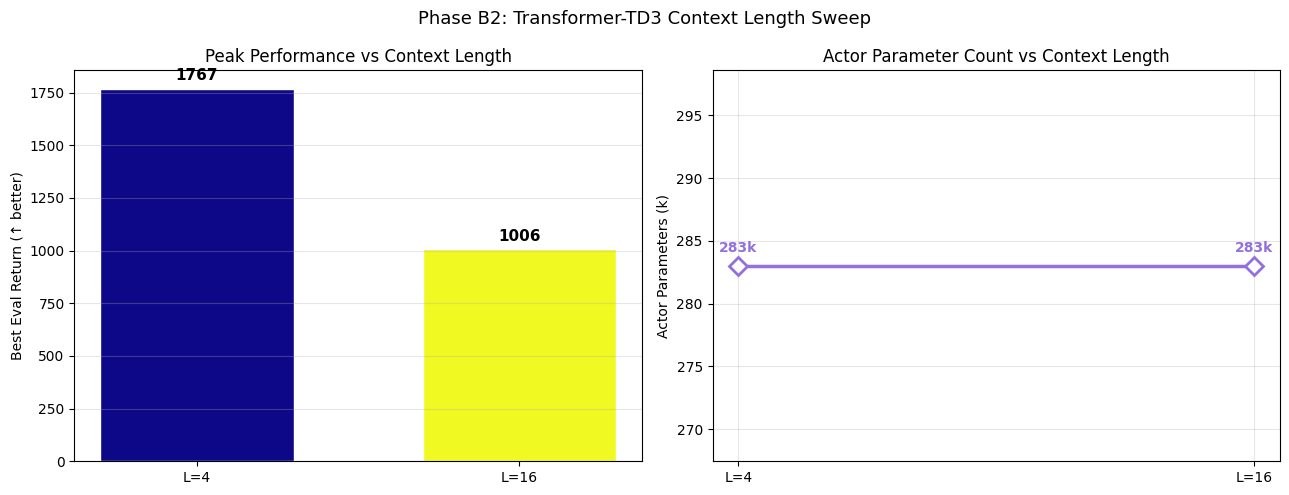

Saved → context_sweep.png

PHASE B2 RESULTS — Transformer-TD3 Context Length Sweep
  Model                        Best Return   Final Return     Params
--------------------------------------------------------------------
  Transformer L=4                   1766.9          720.3       283k
  Transformer L=16                  1005.8          449.3       283k

Saved → rl_phase2_summary.json  (used by Phase B3)


In [13]:
# ── Load Phase B1 baseline ────────────────────────────────────────────────
try:
    with open("rl_phase1_td3_summary.json") as f:
        b1 = json.load(f)
    b1_return = b1["final_mean_return"]
    b1_curve  = b1.get("eval_curve", {})
    print(f"Phase B1 baseline loaded: {b1_return:.1f}")
except FileNotFoundError:
    b1_return = None; b1_curve = {}
    print("Phase B1 summary not found. Set b1_return manually if needed.")

Ls   = TF_CFG["context_lengths"]
CMAP = plt.cm.plasma
PAL  = {L: CMAP(0.5) for L in Ls} if len(Ls) == 1 else {L: CMAP(i / (len(Ls)-1)) for i, L in enumerate(Ls)}

# ── Figure 1: Evaluation learning curves ─────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

if b1_curve.get("steps"):
    ax.plot(b1_curve["steps"], b1_curve["means"],
            "--", color="black", lw=2.5, alpha=0.75, zorder=5,
            label="MLP-TD3 baseline (Phase B1)")

for L in Ls:
    hist = all_histories[L]
    if not hist["eval_steps"]: continue
    means = np.array(hist["eval_means"])
    stds  = np.array(hist["eval_stds"])
    steps = np.array(hist["eval_steps"])
    ax.plot(steps, means, "o-", color=PAL[L], lw=2, ms=4, label=f"Transformer L={L}")
    ax.fill_between(steps, means-stds, means+stds, alpha=0.12, color=PAL[L])

for val, col, lbl in [(1000,"green","1k (basic)"),(2500,"orange","2.5k (good)"),(3000,"red","3k (excellent)")]:
    ax.axhline(val, color=col, linestyle=":", alpha=0.4, lw=1.5, label=lbl)

ax.set(xlabel="Environment Steps", ylabel="Mean Evaluation Return (10 episodes)",
       title="Transformer-TD3 vs MLP-TD3 on Hopper-v5")
ax.legend(loc="upper left", fontsize=9); ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))
plt.tight_layout(); plt.savefig("tf_td3_curves.png", dpi=150); plt.show()
print("Saved → tf_td3_curves.png")

# ── Figure 2: Best return & actor params vs L ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

best_returns = [max(all_histories[L]["eval_means"]) if all_histories[L]["eval_means"]
                else 0 for L in Ls]
actor_params = []
for L in Ls:
    kw = {k:v for k,v in TF_CFG.items() if k != "context_lengths"}
    _t = TransformerActor(STATE_DIM, ACTION_DIM, MAX_ACTION, L, **kw)
    actor_params.append(sum(p.numel() for p in _t.parameters()))
    del _t

ax = axes[0]
bars = ax.bar([f"L={L}" for L in Ls], best_returns,
              color=[PAL[L] for L in Ls], edgecolor="white", width=0.6)
ax.bar_label(bars, fmt="%.0f", padding=4, fontsize=11, fontweight="bold")
if b1_return:
    ax.axhline(b1_return, color="black", linestyle="--", lw=2,
               label=f"MLP baseline ({b1_return:.0f})")
    ax.legend(fontsize=10)
ax.set(ylabel="Best Eval Return (↑ better)",
       title="Peak Performance vs Context Length")
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
ax.plot([f"L={L}" for L in Ls], [n/1000 for n in actor_params],
        "D-", color="mediumpurple", lw=2.5, ms=9, markerfacecolor="white",
        markeredgewidth=2)
for i, (L, n) in enumerate(zip(Ls, actor_params)):
    ax.annotate(f"{n//1000}k", (i, n/1000),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=10, fontweight="bold",
                color="mediumpurple")
ax.set(ylabel="Actor Parameters (k)",
       title="Actor Parameter Count vs Context Length")
ax.grid(alpha=0.3)

plt.suptitle("Phase B2: Transformer-TD3 Context Length Sweep", fontsize=13)
plt.tight_layout(); plt.savefig("context_sweep.png", dpi=150); plt.show()
print("Saved → context_sweep.png")

# ── Results table ─────────────────────────────────────────────────────────
print("\n" + "="*68)
print("PHASE B2 RESULTS — Transformer-TD3 Context Length Sweep")
print("="*68)
print(f"  {'Model':<26}  {'Best Return':>12}  {'Final Return':>13}  {'Params':>9}")
print("-"*68)
if b1_return:
    print(f"  {'MLP-TD3 (Phase B1)':<26}  {b1_return:>12.1f}  {'—':>13}  {'~100k':>9}")
for L, n, best in zip(Ls, actor_params, best_returns):
    final = all_histories[L]["eval_means"][-1] if all_histories[L]["eval_means"] else 0
    print(f"  {'Transformer L='+str(L):<26}  {best:>12.1f}  {final:>13.1f}  {n//1000:>8}k")
print("="*68)

# Save summary for Phase B3
summary = {
    "context_lengths": Ls,
    "baseline_mlp_return": b1_return,
    "results": {
        str(L): {
            "best_return"  : best_returns[i],
            "final_return" : all_histories[L]["eval_means"][-1]
                             if all_histories[L]["eval_means"] else 0,
            "actor_params" : actor_params[i],
            "eval_steps"   : all_histories[L]["eval_steps"],
            "eval_means"   : all_histories[L]["eval_means"],
            "eval_stds"    : all_histories[L]["eval_stds"],
        }
        for i, L in enumerate(Ls)
    },
}
with open("rl_phase2_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("\nSaved → rl_phase2_summary.json  (used by Phase B3)")


Analysing attention for best context length: L=4  (return=1766.9)


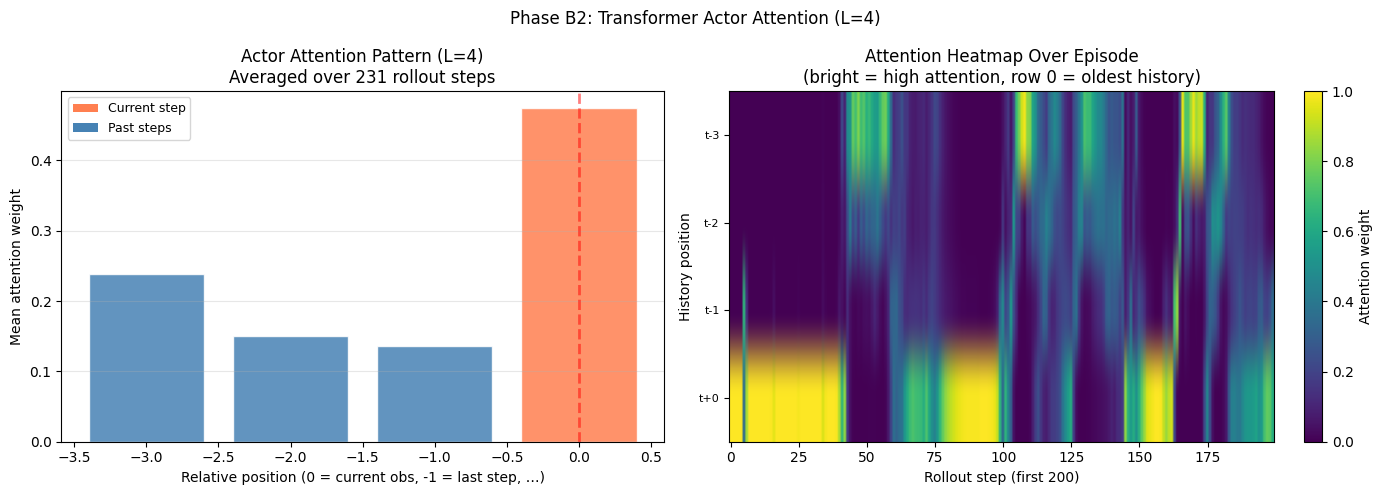

Saved → actor_attention.png

Mean attention weight by relative position (L=4):
   -3: 0.2385  ███████████  
   -2: 0.1510  ███████  
   -1: 0.1357  ██████  
   +0: 0.4748  ███████████████████████  ← current


In [14]:
# ── Attention pattern analysis on best context length ─────────────────────
BEST_L = Ls[int(np.argmax(best_returns))]
agent_best = all_agents[BEST_L]
print(f"Analysing attention for best context length: L={BEST_L}  "
      f"(return={max(best_returns):.1f})")

# Run a deterministic episode, collect attention at every step
eval_env = gym.make(TD3_CFG["env_name"])
obs, _   = eval_env.reset(seed=99)
hist_vis = ObsActionHistory(STATE_DIM, ACTION_DIM, BEST_L)
step_attns = []   # list of (L,) vectors

agent_best.actor.eval()
with torch.no_grad():
    for step_i in range(500):
        seq   = hist_vis.get_sequence(obs)
        seq_t = torch.tensor(seq, dtype=torch.float32,
                             device=DEVICE).unsqueeze(0)   # (1, L, obs+act)
        action, attn_list = agent_best.actor.get_attn_weights(seq_t)
        action = action.squeeze(0).cpu().numpy()

        # Last layer, first head, last query position → how much does
        # the current-step query attend to each history position?
        last_layer_attn = attn_list[-1][0, 0, -1, :].cpu().numpy()  # (L,)
        step_attns.append(last_layer_attn)

        hist_vis.push(obs, action)
        obs, _, terminated, truncated, _ = eval_env.step(action)
        if terminated or truncated: break

eval_env.close()
agent_best.actor.train()

step_attns  = np.array(step_attns)   # (n_steps, L)
mean_attn   = step_attns.mean(axis=0)
rel_pos     = np.arange(BEST_L) - (BEST_L - 1)  # 0=current, -1=1 step ago, ...

# ── Figure 3: Attention weights ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors = ["coral" if p == 0 else "steelblue" for p in rel_pos]
ax.bar(rel_pos, mean_attn, color=colors, edgecolor="white", alpha=0.85)
ax.set(xlabel="Relative position (0 = current obs, -1 = last step, …)",
       ylabel="Mean attention weight",
       title=f"Actor Attention Pattern (L={BEST_L})\n"
             f"Averaged over {len(step_attns)} rollout steps")
ax.axvline(0, color="red", lw=2, linestyle="--", alpha=0.5, label="Current obs")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="coral", label="Current step"),
                   Patch(facecolor="steelblue", label="Past steps")],
          fontsize=9)
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
n_show = min(200, len(step_attns))
im = ax.imshow(step_attns[:n_show].T, aspect="auto", cmap="viridis",
               origin="upper", vmin=0, vmax=step_attns[:n_show].max())
ax.set_yticks(range(BEST_L))
ax.set_yticklabels([f"t{p:+d}" for p in rel_pos], fontsize=8)
ax.set(xlabel=f"Rollout step (first {n_show})",
       ylabel="History position",
       title="Attention Heatmap Over Episode\n"
             f"(bright = high attention, row 0 = oldest history)")
plt.colorbar(im, ax=ax, fraction=0.046, label="Attention weight")

plt.suptitle(f"Phase B2: Transformer Actor Attention (L={BEST_L})", fontsize=12)
plt.tight_layout(); plt.savefig("actor_attention.png", dpi=130); plt.show()
print("Saved → actor_attention.png")

# ── Mean attention vs relative distance summary ───────────────────────────
print(f"\nMean attention weight by relative position (L={BEST_L}):")
for rp, w in sorted(zip(rel_pos, mean_attn)):
    bar = "█" * int(w * 50)
    label = "← current" if rp == 0 else ""
    print(f"  {rp:+3d}: {w:.4f}  {bar}  {label}")


In [15]:
# ── Save best model to Google Drive (optional) ────────────────────────────
# Uncomment to persist the final checkpoints:
#
# from google.colab import drive
# import shutil
# drive.mount('/content/drive')
# DRIVE = "/content/drive/MyDrive/saidl2026/rl_b2"
# os.makedirs(DRIVE, exist_ok=True)
# for L in TF_CFG["context_lengths"]:
#     label = f"TransformerTD3_L{L}"
#     src = f"{TD3_CFG['save_dir']}/{label}_final.pt"
#     if os.path.exists(src):
#         shutil.copy(src, DRIVE)
#         print(f"  Backed up: {label}_final.pt")
# shutil.copy("rl_phase2_summary.json", DRIVE)
# print("Drive backup complete.")

print("Uncomment the block above to save to Google Drive.")


Uncomment the block above to save to Google Drive.
